In [1]:
import sys, os
sys.path.insert(0, '../../')
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt 
from gasp import load_dataset

import logging
logging.getLogger('gasp.dataset').setLevel(logging.DEBUG)
logging.basicConfig() 

In [ ]:
ds = {
    'path':'2025_10_1_sphere_phantom',
    'filter':'_fa60_'
}
M = load_dataset(**ds, )

ds_fieldmap = { 
    'path':'2025_10_1_sphere_phantom',
    'filter': 'gre_field_mapping',
    'description': 'GRE field mapping with TE1 = 4.92ms and TE2 = 7.38ms'
}
M_fieldmap = load_dataset(**ds_fieldmap)

ds_dixon = {
    'path':'2025_10_1_sphere_phantom',
    'filter': ['_gre_TE3p41', '_gre_TE4p55', '_gre_TE5p68']
}
M_dixon = load_dataset(**ds_dixon)

print('M shape: ', M.shape)
print('M_fieldmap shape: ', M_fieldmap.shape)
print('M_dixon shape: ', M_dixon.shape)

DEBUG:gasp.dataset:Filter: _fa60_
DEBUG:gasp.dataset:Loading from: /Users/michael/projects/mri/GASP/notebooks/datasets/../../gasp/../data/2025_10_1_sphere_phantom
DEBUG:gasp.dataset:Files: ['meas_MID231_bSSFP_gasp_knee_fa60_TR7ms_FID84860.dat', 'meas_MID232_bSSFP_gasp_knee_fa60_TR14ms_FID84861.dat', 'meas_MID233_bSSFP_gasp_knee_fa60_TR28ms_FID84862.dat']


pymapVBVD version 0.5.6
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/133M [00:00<?, ?B/s]

read data:   0%|          | 0/4096 [00:00<?, ?it/s]

pymapVBVD version 0.5.6
Software version: VB


...

read data:   0%|          | 0/64 [00:00<?, ?it/s]

pymapVBVD version 0.5.6
Software version: VB


Scan 1/1, read all mdhs:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

M shape:  (256, 256, 8, 16, 3)
M_fieldmap shape:  (128, 128, 8, 2, 1)
M_dixon shape:  (64, 64, 8, 3)


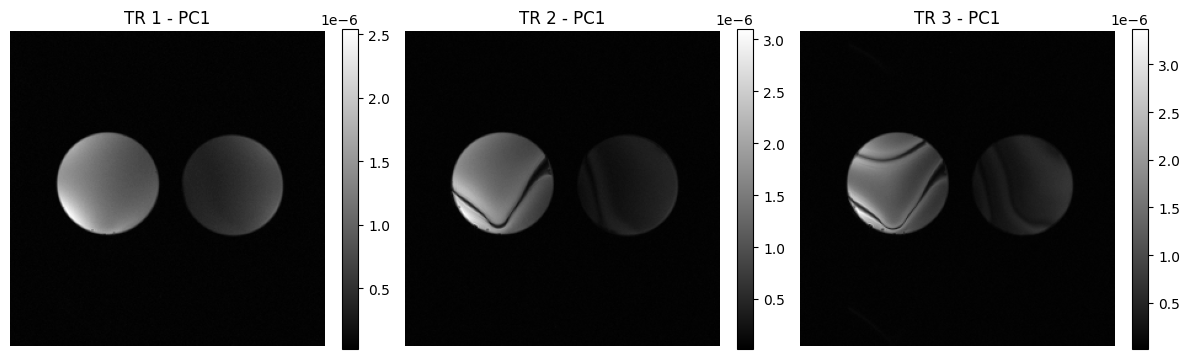

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# M shape: (Height, Width, Coil, PCs, TRs)
# Combine coils using root sum of squares (optimal for magnitude)
M_rss = np.sqrt(np.sum(np.abs(M)**2, axis=2))  # shape: (H, W, PCs, TRs)

# Extract first PC (index 0) for all 3 TRs
first_pc = M_rss[:, :, 0, :]  # shape: (H, W, TRs)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(np.abs(first_pc[:, :, i]), cmap='gray')
    axes[i].set_title(f'TR {i+1} - PC1')
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import zoom

# M_fieldmap shape: (128, 128, 8, 2, 1) - (H, W, Coils, Echoes, TRs)
# TE1 = 4.92ms, TE2 = 7.38ms
TE1 = 4.92e-3  # seconds
TE2 = 7.38e-3  # seconds
delta_TE = TE2 - TE1  # 2.46 ms

# Combine coils using root sum of squares for magnitude-weighted phase
M_fm_te1 = M_fieldmap[:, :, :, 0, 0]  # (128, 128, 8)
M_fm_te2 = M_fieldmap[:, :, :, 1, 0]  # (128, 128, 8)

# Coil-combined phase difference (magnitude-weighted)
# Weight by magnitude to reduce noise in low-signal regions
magnitude = np.sqrt(np.sum(np.abs(M_fm_te1)**2 + np.abs(M_fm_te2)**2, axis=2))
phase_diff_per_coil = np.angle(M_fm_te2 * np.conj(M_fm_te1))

# Weighted average of phase difference across coils
weights = np.abs(M_fm_te1) * np.abs(M_fm_te2)
phase_diff = np.angle(np.sum(M_fm_te2 * np.conj(M_fm_te1), axis=2))

# Convert phase difference to Hz
fieldmap_hz = phase_diff / (2 * np.pi * delta_TE)

# Interpolate to match M dimensions (256, 256)
target_shape = M.shape[:2]  # (256, 256)
zoom_factors = (target_shape[0] / fieldmap_hz.shape[0], 
                target_shape[1] / fieldmap_hz.shape[1])
fieldmap_hz_interp = zoom(fieldmap_hz, zoom_factors, order=3)

print(f"Original fieldmap shape: {fieldmap_hz.shape}")
print(f"Interpolated fieldmap shape: {fieldmap_hz_interp.shape}")
print(f"Fieldmap range: {fieldmap_hz_interp.min():.1f} to {fieldmap_hz_interp.max():.1f} Hz")

# Plot original and interpolated fieldmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(fieldmap_hz, cmap='RdBu_r', vmin=-200, vmax=200)
axes[0].set_title(f'Fieldmap (128×128)\nΔTE = {delta_TE*1e3:.2f} ms')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Hz', fraction=0.046)

im1 = axes[1].imshow(fieldmap_hz_interp, cmap='RdBu_r', vmin=-200, vmax=200)
axes[1].set_title(f'Fieldmap Interpolated (256×256)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Hz', fraction=0.046)

# Show magnitude for reference
im2 = axes[2].imshow(zoom(magnitude, zoom_factors, order=3), cmap='gray')
axes[2].set_title('Magnitude (reference)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()